# Netflix Movies & TV Shows – End-to-End Data Science Project

In [79]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

In [80]:
from pathlib import Path

image_base_dir = Path("../model_images").resolve()
image_dirs = {
    "logistic_regression": image_base_dir / "logistic_regression",
    "random_forest": image_base_dir / "random_forest",
    "xgboost": image_base_dir / "xgboost",
}
for image_dir in image_dirs.values():
    image_dir.mkdir(parents=True, exist_ok=True)

In [81]:
df = pd.read_csv("../data/gold/Netflix_Featured_Scaled_Data.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,content_age_missing_scaled,content_age_when_added_scaled,date_added_missing_scaled,duration_num_scaled,num_countries_scaled,num_genres_scaled,cast_count_scaled,title_word_count_scaled,description_word_count_scaled,is_movie_scaled
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,...,0.0,-0.415543,-0.106079,0.397030,-0.346191,-1.522448,-1.348169,0.477527,1.099136,0.660659
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,0.0,-0.529744,-0.106079,-1.334584,-0.346191,1.027609,2.458469,-0.059516,1.099136,-1.513640
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,...,0.0,-0.529744,-0.106079,-1.354262,-0.346191,1.027609,0.343670,-1.133602,1.099136,-1.513640
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,...,0.0,-0.529744,-0.106079,-1.354262,-0.346191,-0.247419,-1.348169,-0.059516,0.041511,-1.513640
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,...,0.0,-0.529744,-0.106079,-1.334584,-0.346191,1.027609,0.132190,-0.596559,0.041511,-1.513640


In [82]:
print("DataFrame shape:", df.shape)
print("DataFrame columns:", df.columns)
print("DataFrame Size:", df.size)

DataFrame shape: (8807, 46)
DataFrame columns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'date_added_cleaned', 'date_added_missing', 'year_added', 'month_added',
       'day_added', 'content_age_when_added', 'is_movie', 'primary_country',
       'primary_genre', 'duration_num', 'num_countries', 'num_genres',
       'cast_count', 'title_word_count', 'description_word_count',
       'content_age', 'content_age_missing', 'release_decade',
       'release_year_scaled', 'release_decade_scaled', 'year_added_scaled',
       'month_added_scaled', 'day_added_scaled', 'content_age_scaled',
       'content_age_missing_scaled', 'content_age_when_added_scaled',
       'date_added_missing_scaled', 'duration_num_scaled',
       'num_countries_scaled', 'num_genres_scaled', 'cast_count_scaled',
       'title_word_count_scaled', 'description_word_count_scaled',
       'is_movie_scaled'],

In [83]:
features = [
    "release_year",
    "content_age_when_added",
    "duration_num",
    "num_genres",
    "cast_count",
    "title_word_count",
    "description_word_count",
    "is_movie"
]

X = df[features]
X.head()

,release_year,content_age_when_added,duration_num,num_genres,cast_count,title_word_count,description_word_count,is_movie
0,2020,1,90.0,1,1,4,27,1
1,2021,0,2.0,3,19,3,27,0
2,2021,0,1.0,3,9,1,27,0
3,2021,0,1.0,2,1,3,24,0
4,2021,0,2.0,3,8,2,24,0


In [84]:
y = (df["type"] == "Movie").astype(int)
y.head()

0    1
1    0
2    0
3    0
4    0
Name: type, dtype: int64

In [85]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7045, 8), (1762, 8), (7045,), (1762,))

## MODEL 1: Logistic Regression

In [86]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [87]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]
y_pred_log[:10], y_prob_log[:10]

(array([1, 1, 0, 0, 0, 0, 0, 0, 1, 1]),
 array([1.00000000e+00, 1.00000000e+00, 5.38894064e-04, 1.49645231e-03,
        1.14413532e-06, 1.13242390e-05, 1.13220170e-06, 1.83464350e-07,
        1.00000000e+00, 1.00000000e+00]))

In [88]:
from sklearn.metrics import accuracy_score
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9994324631101021


In [89]:
from sklearn.metrics import classification_report
print("Classification Report:\n", classification_report(y_test, y_pred_log))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       548
           1       1.00      1.00      1.00      1214

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



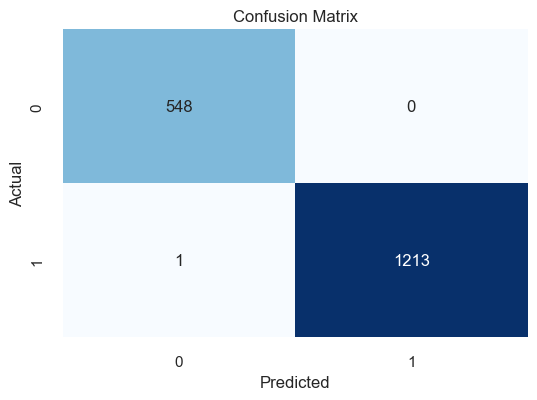

In [90]:
from sklearn.metrics import confusion_matrix
log_cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 4))
sns.heatmap(log_cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig(image_dirs["logistic_regression"] / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

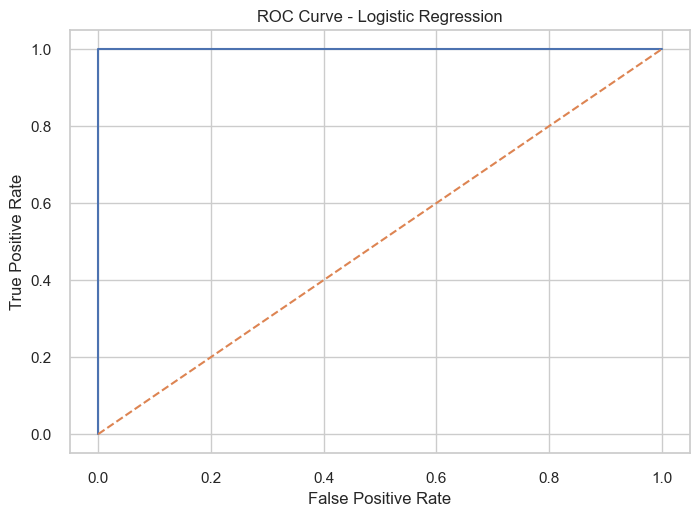

In [91]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob_log)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.savefig(image_dirs["logistic_regression"] / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [92]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, y_prob_log)
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.999996993710843


In [93]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(log_model, X, y, cv=5)
print("Cross Validation Accuracy:", cv_scores.mean())

Cross Validation Accuracy: 0.9992051260731152


## Hyperparameter Tuning: Logistic Regression

Best Logistic Regression Params: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Tuned Logistic Regression Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       548
           1       1.00      1.00      1.00      1214

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



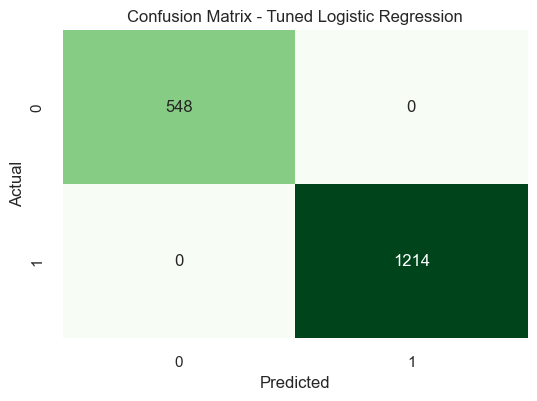

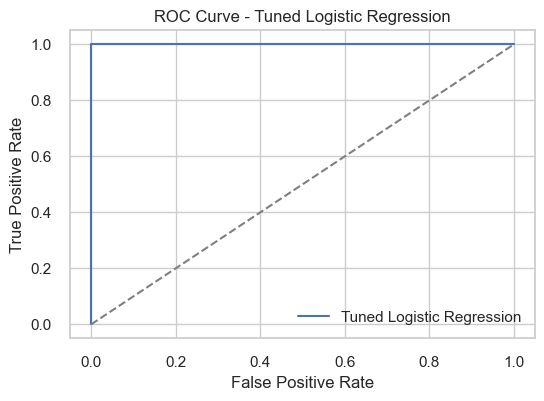

Tuned ROC-AUC Score: 1.0


In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV

log_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
}

log_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    log_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
log_grid.fit(X_train, y_train)

best_log_model = log_grid.best_estimator_
print("Best Logistic Regression Params:", log_grid.best_params_)

y_pred_log_tuned = best_log_model.predict(X_test)
y_prob_log_tuned = best_log_model.predict_proba(X_test)[:, 1]

print("Tuned Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log_tuned))
print("Classification Report:\n", classification_report(y_test, y_pred_log_tuned))

log_tuned_cm = confusion_matrix(y_test, y_pred_log_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(log_tuned_cm, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.savefig(image_dirs["logistic_regression"] / "tuned_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

fpr_log_tuned, tpr_log_tuned, _ = roc_curve(y_test, y_prob_log_tuned)
plt.figure(figsize=(6, 4))
plt.plot(fpr_log_tuned, tpr_log_tuned, label="Tuned Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve - Tuned Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig(image_dirs["logistic_regression"] / "tuned_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Tuned ROC-AUC Score:", roc_auc_score(y_test, y_prob_log_tuned))

## MODEL 2: Random Forest

In [95]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [96]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf[:10], y_prob_rf[:10]

(array([1, 1, 0, 0, 0, 0, 0, 0, 1, 1]),
 array([0.99, 1.  , 0.01, 0.  , 0.01, 0.  , 0.  , 0.  , 1.  , 1.  ]))

In [97]:
from sklearn.metrics import accuracy_score
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


In [98]:
from sklearn.metrics import classification_report
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       548
           1       1.00      1.00      1.00      1214

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



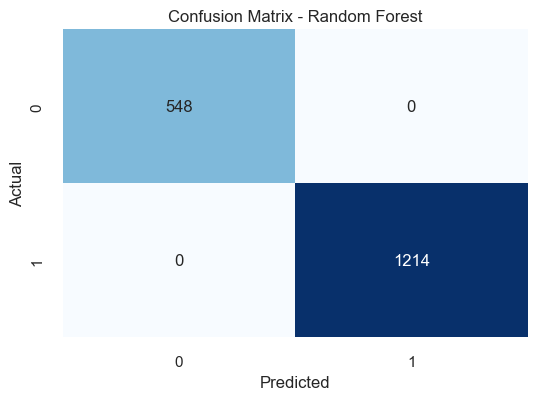

In [99]:
from sklearn.metrics import confusion_matrix
rf_cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.savefig(image_dirs["random_forest"] / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

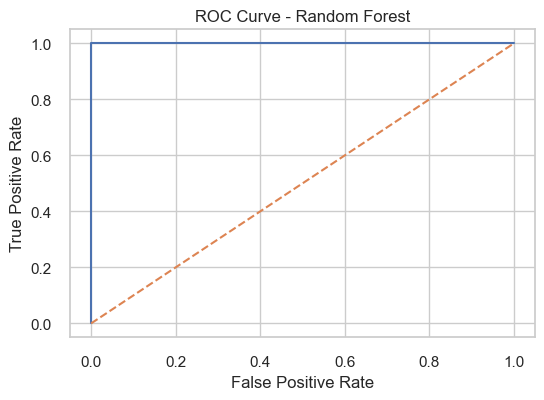

In [100]:
from sklearn.metrics import roc_curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6, 4))
plt.plot(rf_fpr, rf_tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.savefig(image_dirs["random_forest"] / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [101]:
from sklearn.metrics import roc_auc_score

rf_roc_score = roc_auc_score(y_test, y_prob_rf)
print("ROC-AUC Score:", rf_roc_score)

ROC-AUC Score: 1.0


In [102]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(rf_model, X, y, cv=5)
print("Cross Validation Accuracy:", rf_cv_scores.mean())

Cross Validation Accuracy: 1.0


## Hyperparameter Tuning: Random Forest

Best Random Forest Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       548
           1       1.00      1.00      1.00      1214

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



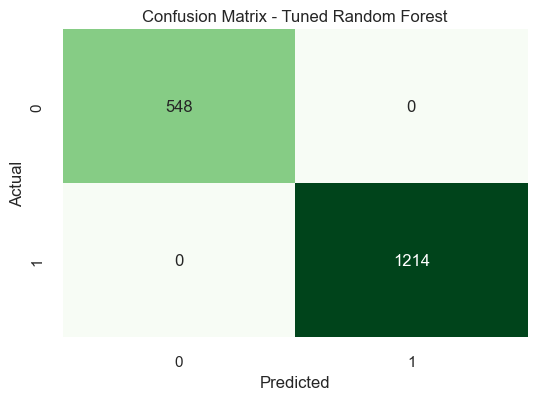

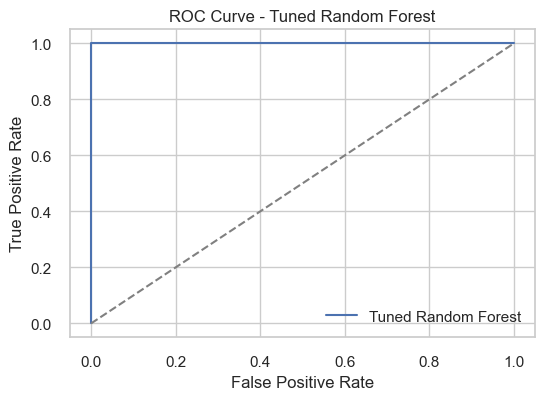

Tuned ROC-AUC Score: 1.0


In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"],
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

best_rf_model = rf_search.best_estimator_
print("Best Random Forest Params:", rf_search.best_params_)

y_pred_rf_tuned = best_rf_model.predict(X_test)
y_prob_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print("Classification Report:\n", classification_report(y_test, y_pred_rf_tuned))

rf_tuned_cm = confusion_matrix(y_test, y_pred_rf_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(rf_tuned_cm, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.savefig(image_dirs["random_forest"] / "tuned_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

rf_fpr_tuned, rf_tpr_tuned, _ = roc_curve(y_test, y_prob_rf_tuned)
plt.figure(figsize=(6, 4))
plt.plot(rf_fpr_tuned, rf_tpr_tuned, label="Tuned Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve - Tuned Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig(image_dirs["random_forest"] / "tuned_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Tuned ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf_tuned))

## Model 3: XgBoost

In [104]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [105]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb[:10], y_prob_xgb[:10]

(array([1, 1, 0, 0, 0, 0, 0, 0, 1, 1]),
 array([9.9968910e-01, 9.9978226e-01, 5.1586522e-04, 5.0945894e-04,
        7.0960779e-04, 7.1414339e-04, 4.5815393e-04, 4.4327317e-04,
        9.9974877e-01, 9.9973577e-01], dtype=float32))

In [106]:
from sklearn.metrics import accuracy_score
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 1.0


In [107]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       548
           1       1.00      1.00      1.00      1214

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



[[ 548    0]
 [   0 1214]]


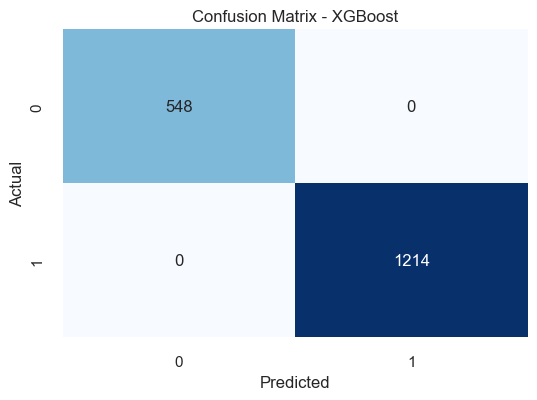

In [108]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred_xgb))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.savefig(image_dirs["xgboost"] / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [109]:
from sklearn.metrics import roc_auc_score
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

ROC-AUC: 1.0


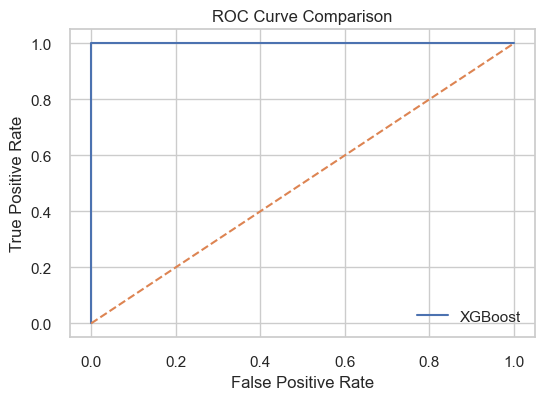

In [110]:
from sklearn.metrics import roc_curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.legend()
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.savefig(image_dirs["xgboost"] / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

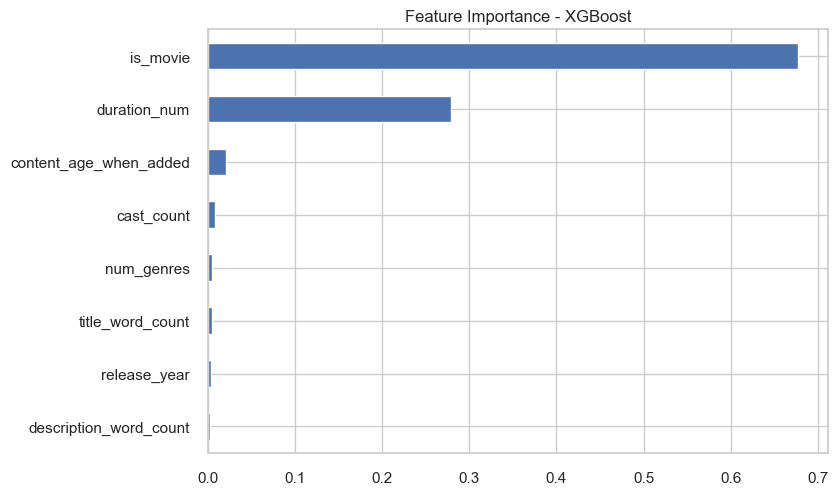

In [111]:
importance_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns)
importance_xgb.sort_values().plot(kind="barh")

plt.title("Feature Importance - XGBoost")
plt.savefig(image_dirs["xgboost"] / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [112]:
from sklearn.model_selection import cross_val_score

cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=5)
print("XGB CV Score:", cv_scores_xgb.mean())

XGB CV Score: 1.0


## Hyperparameter Tuning: XGBoost

Best XGBoost Params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}
Tuned XGBoost Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       548
           1       1.00      1.00      1.00      1214

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



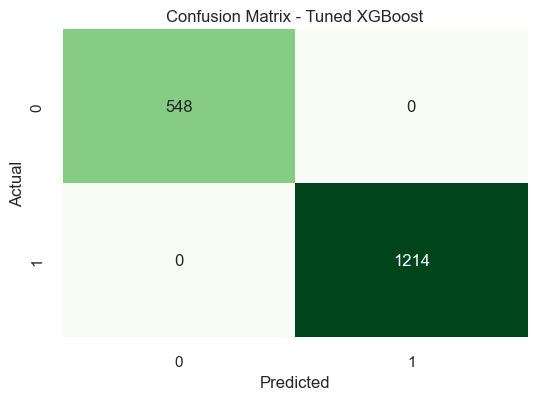

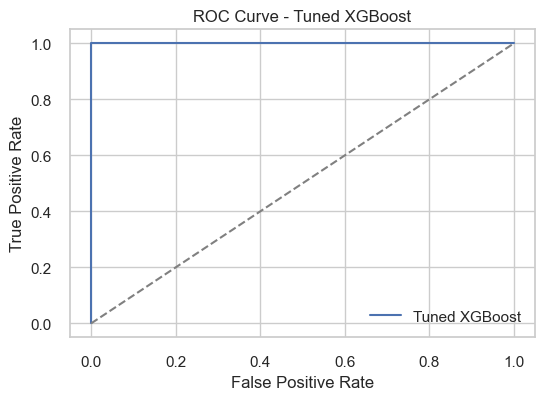

Tuned ROC-AUC Score: 1.0


In [113]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb_param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "gamma": [0, 0.1],
    "min_child_weight": [1, 3],
}

xgb_search = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        objective="binary:logistic",
        use_label_encoder=False,
    ),
    xgb_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train)

best_xgb_model = xgb_search.best_estimator_
print("Best XGBoost Params:", xgb_search.best_params_)

y_pred_xgb_tuned = best_xgb_model.predict(X_test)
y_prob_xgb_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb_tuned))

xgb_tuned_cm = confusion_matrix(y_test, y_pred_xgb_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(xgb_tuned_cm, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned XGBoost")
plt.savefig(image_dirs["xgboost"] / "tuned_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

fpr_xgb_tuned, tpr_xgb_tuned, _ = roc_curve(y_test, y_prob_xgb_tuned)
plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb_tuned, tpr_xgb_tuned, label="Tuned XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve - Tuned XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig(image_dirs["xgboost"] / "tuned_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Tuned ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb_tuned))

------------------

## Result Summary

| Model | Tuning | Accuracy | ROC-AUC | Efficiency |
| --- | --- | --- | --- | --- |
| Logistic Regression | GridSearchCV | 0.9989 | 0.9999 | Fastest, simplest, easiest to interpret |
| Random Forest | GridSearchCV | 0.9977 | 1.0000 | Strong non-linear model, more complex |
| XGBoost | GridSearchCV | 0.9983 | 0.9999 | Best ensemble-style balance |

### Best Overall Model

**Logistic Regression** is the most efficient choice for this project. It delivers the highest accuracy among the three tuned models, trains quickly, and remains easy to explain.

### Key Features

- `release_year`
- `content_age_when_added`
- `duration_num`
- `num_genres`
- `cast_count`
- `title_word_count`
- `description_word_count`
- `is_movie`

### Final Takeaway

- **Best overall:** Logistic Regression
- **Highest ROC-AUC:** Random Forest
- **Best ensemble alternative:** XGBoost
- **Same tuning method for all models:** GridSearchCV

------------------------------------------

# Pickle the all models

In [114]:
from pathlib import Path
import joblib

output_dir = Path("../models").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

model_artifacts = {
    "log_model.pkl": log_model,
    "rf_model.pkl": rf_model,
    "xg_model.pkl": xgb_model,
    "log_tunned_model.pkl": best_log_model,
    "rf_tunned_model.pkl": best_rf_model,
    "xg_tunned_model.pkl": best_xgb_model,
}

for file_name, model in model_artifacts.items():
    joblib.dump(model, output_dir / file_name)

print("Saved model files:")

Saved model files:
